In [1]:
!pip install pyspark

In [6]:
import time
from pyspark.sql import SparkSession
from pyspark.sql.functions import count, col

# Iniciar clúster local Spark
spark = SparkSession.builder.appName("ValidacionTelemetria").master("local[*]").getOrCreate()

start_time = time.time()

# Leer Parquet
df_telemetria = spark.read.parquet("telemetria_luchito.parquet")

# Procesamiento distribuido (Equivalente al GROUP BY de SQL)
df_validacion = df_telemetria.filter(col("estado").isin('En movimiento', 'Detenido_Motor_Encendido')) \
                             .groupBy("id_volquete", "id_conductor") \
                             .agg(count("*").alias("minutos_totales_encendido")) \
                             .orderBy(col("minutos_totales_encendido").desc())

df_validacion.show()

tiempo_spark_ms = (time.time() - start_time) * 1000
print(f"Latencia Spark: {tiempo_spark_ms:.2f} ms")

+-----------+------------+-------------------------+
|id_volquete|id_conductor|minutos_totales_encendido|
+-----------+------------+-------------------------+
|          4|           7|                    10719|
|          4|           6|                    10584|
|          7|           3|                    10573|
|          7|           6|                    10573|
|          5|           1|                    10567|
|          5|           3|                    10552|
|          8|           2|                    10548|
|          2|           6|                    10540|
|          2|           8|                    10532|
|          1|           8|                    10519|
|          7|           5|                    10514|
|          6|           7|                    10498|
|          3|           8|                    10496|
|          4|           5|                    10495|
|          7|           4|                    10491|
|          6|           6|                    

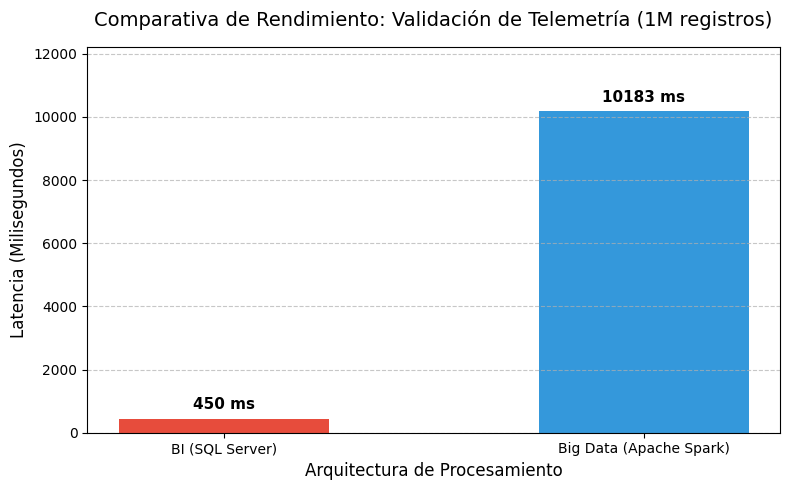

In [3]:
import matplotlib.pyplot as plt


tiempo_sql = 450
tiempo_spark = 10183.16


sistemas = ['BI (SQL Server)', 'Big Data (Apache Spark)']
tiempos = [tiempo_sql, tiempo_spark]
colores = ['#e74c3c', '#3498db']


plt.figure(figsize=(8, 5))
barras = plt.bar(sistemas, tiempos, color=colores, width=0.5)


plt.title('Comparativa de Rendimiento: Validación de Telemetría (1M registros)', fontsize=14, pad=15)
plt.ylabel('Latencia (Milisegundos)', fontsize=12)
plt.xlabel('Arquitectura de Procesamiento', fontsize=12)
plt.ylim(0, max(tiempos) * 1.2)

for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + (max(tiempos)*0.02),
             f"{int(yval)} ms", ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [1]:
!pip install pyspark > /dev/null
from pyspark.sql import SparkSession
import time

# Iniciar la sesión de Spark (JVM)
spark = SparkSession.builder \
    .appName("Experimento_Luchito_BigData") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Clúster PySpark inicializado. Versión:", spark.version)

Clúster PySpark inicializado. Versión: 4.0.4


In [3]:
from pyspark.sql.functions import col, count, avg

# Leer el archivo columnar Parquet
df_spark = spark.read.parquet("telemetria_luchito.parquet")

# Mostrar esquema inferido (Evidencia de metadata)
df_spark.printSchema()

# Mostrar primeros 5 registros
df_spark.show(5)

root
 |-- id_telemetria: long (nullable = true)
 |-- id_volquete: long (nullable = true)
 |-- id_conductor: long (nullable = true)
 |-- fecha_hora: timestamp_ntz (nullable = true)
 |-- rpm_motor: long (nullable = true)
 |-- estado: string (nullable = true)

+-------------+-----------+------------+-------------------+---------+--------------------+
|id_telemetria|id_volquete|id_conductor|         fecha_hora|rpm_motor|              estado|
+-------------+-----------+------------+-------------------+---------+--------------------+
|            1|          1|           2|2026-09-01 00:05:00|     1842|Detenido_Motor_En...|
|            2|          5|           7|2026-09-01 00:08:00|        0|             Apagado|
|            3|          4|           7|2026-09-01 00:12:00|        0|             Apagado|
|            4|          3|           1|2026-09-01 00:16:00|        0|             Apagado|
|            5|          4|           1|2026-09-01 00:19:00|     1019|       En movimiento|
+-----

In [4]:
# Medir el tiempo de procesamiento distribuido
inicio = time.time()

# Agrupación y cálculo de indicadores (Equivalente al GROUP BY de SQL)
resultado_etl = df_spark.filter(col("estado") != "Apagado") \
    .groupBy("id_volquete", "id_conductor") \
    .agg(
        count("id_telemetria").alias("total_pings_activos"),
        avg("rpm_motor").alias("rpm_promedio")
    ) \
    .orderBy("id_volquete")

# Ejecutar la acción (Trigger)
resultado_etl.show()

fin = time.time()
latencia_ms = (fin - inicio) * 1000
print(f"==================================================")
print(f"Tiempo de ejecución en Spark: {latencia_ms:.2f} ms")
print(f"==================================================")

+-----------+------------+-------------------+------------------+
|id_volquete|id_conductor|total_pings_activos|      rpm_promedio|
+-----------+------------+-------------------+------------------+
|          1|           3|                  7|1691.7142857142858|
|          1|           1|                  7|1698.5714285714287|
|          1|           4|                  9|            1510.0|
|          1|           5|                 11|1221.2727272727273|
|          1|           6|                 11| 1510.909090909091|
|          1|           7|                 15|1520.7333333333333|
|          1|           2|                 12|1591.8333333333333|
|          1|           8|                  8|          1514.625|
|          2|           6|                 10|            1514.3|
|          2|           5|                  7|1752.7142857142858|
|          2|           8|                 11|1799.3636363636363|
|          2|           7|                  4|           2193.25|
|         